In [14]:
using Pkg;
Pkg.activate("../../SchrodingerEquationSolver");
include("../src/SchrodingerEquationSolver.jl");
import .SchrodingerEquationSolver as ses
import .ses.Grids as Grids
import .ses.Potentials as Potentials
import .ses.MathUtils as MathUtils
import .ses.Hydrogen as Hydrogen
import .ses.InitialConditions as InitialConditions
import .ses.OneDSchrodingerEquationSolver as odses
import .ses.EigenvalueFinders as EigenvalueFinders
import .ses.IntegralNumericalMethods as IntegralNumericalMethods
using Plots

  Activating project at `~/Desktop/physics_coding_projects/julia/SchrodingerEquationSolver`


In [15]:
#Define parameters and produce an exponential grid.
r_max::Float64=50.0;
Z::Int64=10; #Atomic number, also used as the charge of coulomb potential.
grid= ses.Grids.exponential_grid(r_max, Z);

In [16]:
n::Float64=2.0; #shell level
E= -0.5*(Z^2 / n^2); #Energy of hydrogenic atom
#Definition of initial conditions
l::Int64=1;
init_valu1_fwrd, init_valu2_fwrd,
init_valu1_bwrd, init_valu2_bwrd =InitialConditions.atom(grid, E, l);
print(E)

-12.5

In [17]:

v_colu= Potentials.coulomb_potential(Z, grid);
v_angu= Potentials.angular_potential(l, grid);
v_effe= v_colu + v_angu;

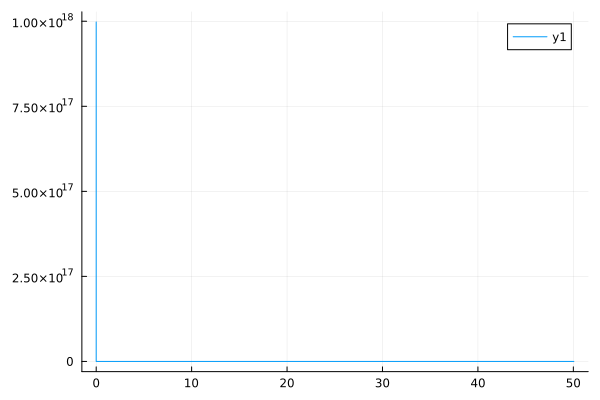

In [18]:
plot(grid, v_effe)
#plot(size=(900,400))

In [19]:
f::Vector{Float64}= 2.0.*(v_effe .- E);
g=zeros(Float64, size(f)[1]);
turn_pnts= MathUtils.indices_of_zeros_finder(f);

In [20]:
turn_pnts

2-element Vector{Int64}:
 5427
 6193

In [21]:
v_effe[turn_pnts[1]]

-12.36798919677112

In [22]:
v_effe[turn_pnts[1]+1]

-12.5075369180053

In [44]:
v_effe[turn_pnts[1]-1]

-12.227341811109937

In [24]:
v_effe[turn_pnts[end]]

-12.500613081156619

In [25]:
v_effe[turn_pnts[end]+1]

-12.476769642592174

In [26]:
v_effe[turn_pnts[end]-1]

-12.524488719903541

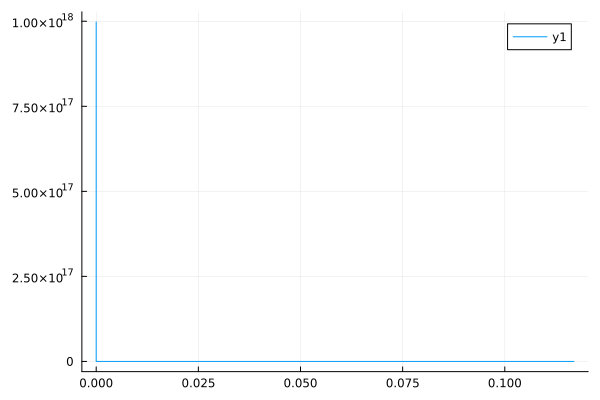

In [28]:
plot(grid[1:turn_pnts[1]], v_effe[1:turn_pnts[1]])

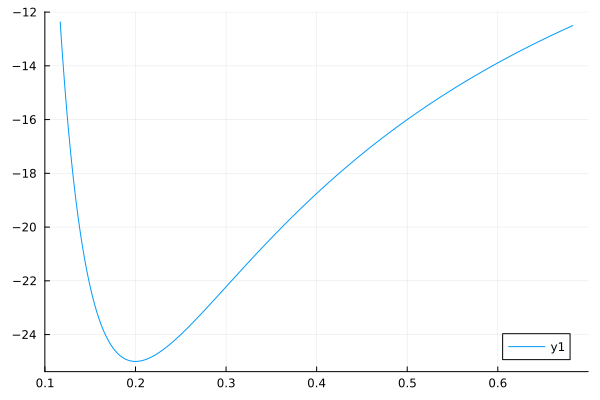

In [29]:
plot(grid[turn_pnts[1]:turn_pnts[2]], v_effe[turn_pnts[1]:turn_pnts[2]])

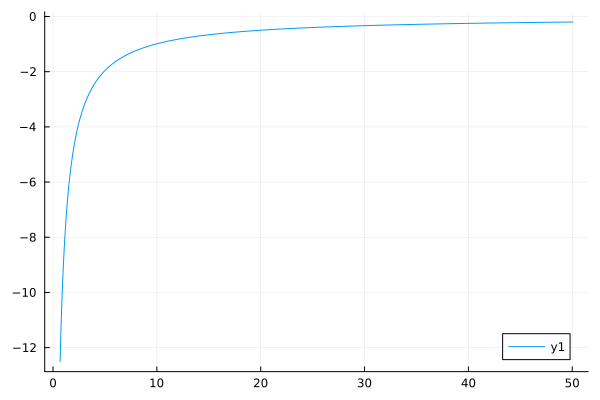

In [30]:
plot(grid[turn_pnts[2]:end], v_effe[turn_pnts[2]:end])

In [31]:
u_fwd= IntegralNumericalMethods.integrate_second_order_DE_RK4_PCABM5(grid,g,f,
init_valu1_fwrd,init_valu2_fwrd);
#do backward integreation of the radial shcrodinger equation u 
u_bwd= reverse(IntegralNumericalMethods.integrate_second_order_DE_RK4_PCABM5(reverse(grid),g,reverse(f),
init_valu1_bwrd,init_valu2_bwrd));

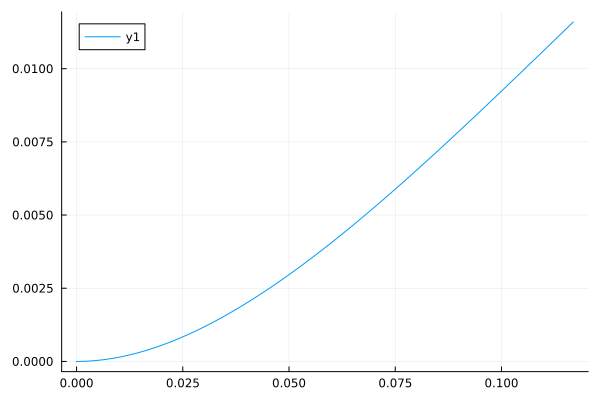

In [40]:
plot(grid[1:turn_pnts[1]], u_fwd[1:turn_pnts[1]])

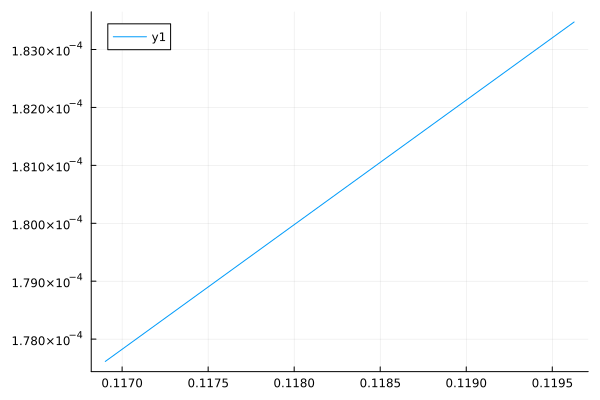

In [41]:
plot(grid[turn_pnts[1]:turn_pnts[1]+10], u_bwd[turn_pnts[1]:turn_pnts[1]+10])

In [39]:
u_fwd1, u_bwd1= MathUtils.rescale!(u_fwd, u_bwd, turn_pnts[1]);

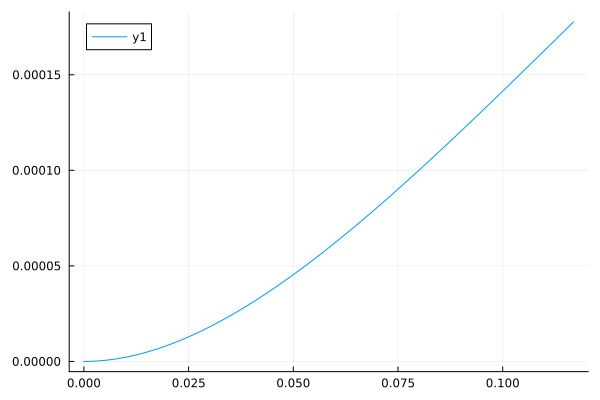

In [42]:
plot(grid[1:turn_pnts[1]], u_fwd1[1:turn_pnts[1]])

In [ ]:
plot(grid[turn_pnts[1]:turn_pnts[1]+10], u_bwd[turn_pnts[1]:turn_pnts[1]+10])